------------------
```markdown
# Copyright © 2025 Meysam Goodarzi
This notebook is licensed under CC BY-NC 4.0 with the following amandments:
- Individuals may use, share, and adapt this material for non-commercial purposes with attribution.
- Institutions/Companies must obtain written consent to use this material, except for nonprofits.
- Commercial use is prohibited without permission.  
Contact: analytica@meysam-goodarzi.com
```
------------------------------
❗❗❗ **IMPORTANT**❗❗❗ **Create a copy of this notebook**

In order to work with this Google Colab you need to create a copy of it. Please **DO NOT** provide your answers here. Instead, work on the copy version. To make a copy:

**Click on: File -> save a copy in drive**

Have you successfully created the copy? if yes, there must be a new tab opened in your browser. Now move to the copy and start from there!

----------------------------------------------


# Bayesian Reasoning Fundamentals with PyMC

## Learning Objectives

By the end of this notebook, you will be able to:
1. Understand the core philosophy of Bayesian inference
2. Build and run simple PyMC models
3. Interpret posterior distributions
4. Perform basic model diagnostics

In [1]:
import pymc as pm
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

# Set random seed for reproducibility
np.random.seed(42)

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
az.style.use("arviz-darkgrid")

## Bayesian Statistics & Thoeorem

Bayesian statistics is fundamentally about
- **Updating beliefs in light of new evidence**
- **Incoporating the notion of uncertainty in forming our understanding of reality**
- **Always taking into account the possibility of another probable hypothesis**

At the heart of Bayesian inference is Bayes' Theorem:

$$P(\theta | D) = \frac{P(D | \theta) \cdot P(\theta)}{P(D)}$$

Where:
- $P(\theta | D)$ = **Posterior**: What we believe about parameter $\theta$ *after* seeing data $D$
- $P(D | \theta)$ = **Likelihood**: How probable is our data given different values of $\theta$
- $P(\theta)$ = **Prior**: What we believe about $\theta$ *before* seeing data
- $P(D)$ = **Evidence**: The probability of the data (normalizing constant)

In a simple language we can say

**Posterior = (Likelihood × Prior) / Evidence**

Or:

**Updated Beliefs = (Data Evidence × Prior Beliefs) / Normalizer**

### Bayesian vs Frequentist

It is always useful to compare a paradaigm with a parallel competing one to deepen our understanding of it. Here are the fundamental difference between Bayesian and Frequentist statistics:

| Aspect | Frequentist | Bayesian |
|--------|-------------|----------|
| Parameters | Fixed but unknown | Random variables with distributions |
| Probability | Long-run frequency | Degree of belief |
| Inference | Point estimates + confidence intervals | Full posterior distributions |
| Prior knowledge | Cannot incorporate | Naturally incorporates |
| Result | "The probability of seeing data this extreme if null is true" | "The probability that our hypothesis is true given the data" |

### Visual Intuition

Let's visualize how Bayesian inference works with a simple example.

/tmp/ipykernel_347/3726782430.py:38: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


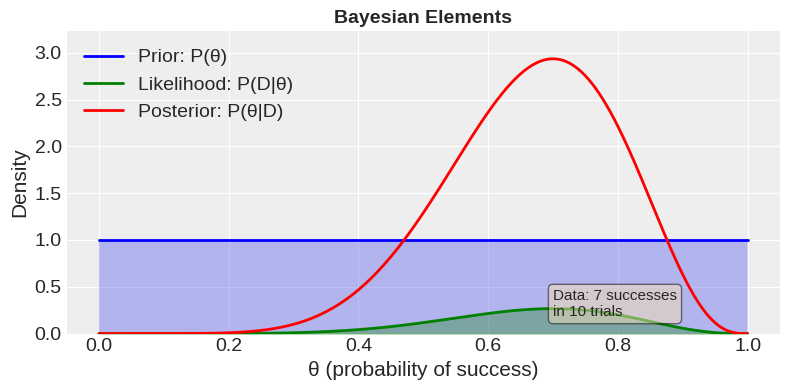

In [2]:
# Create a visualization of the Bayesian update process
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

# Parameter space
theta = np.linspace(0, 1, 1000)

# Prior: We believe the parameter is around 0.5 (uniform prior)
prior = np.ones_like(theta)
prior = prior / np.trapezoid(prior, theta)  # Normalize

# Likelihood: We observed 7 successes out of 10 trials
likelihood = stats.binom.pmf(7, 10, theta)

# Posterior: Combination of prior and likelihood
posterior = likelihood * prior
posterior = posterior / np.trapezoid(posterior, theta)  # Normalize

# Plot Prior
ax.plot(theta, prior, 'b-', linewidth=2, label='Prior: P(θ)')
ax.fill_between(theta, prior, alpha=0.3)

# Plot Likelihood
ax.plot(theta, likelihood, 'g-', linewidth=2, label='Likelihood: P(D|θ)')
ax.fill_between(theta, likelihood, alpha=0.3, color='green')
ax.annotate('Data: 7 successes\nin 10 trials', xy=(0.7, likelihood.max()*0.7),
                fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot Posterior
ax.plot(theta, posterior, 'r-', linewidth=2, label='Posterior: P(θ|D)')
# ax.fill_between(theta, posterior, alpha=0.3, color='red')
ax.set_title('Bayesian Elements', fontsize=14, fontweight='bold')
ax.set_xlabel('θ (probability of success)')
ax.set_ylabel('Density')
ax.set_ylim(0, max(posterior.max(), prior.max()) * 1.1)

ax.legend()

plt.tight_layout()
plt.show()

### Example

You have a coin and want to know if it's fair. You flip it several times and observe the results. What can you conclude about the probability of getting heads?

In [3]:
# Simulate coin flips
np.random.seed(42)
true_p = 0.65  # Unknown true probability (biased coin)
n_flips = 20
coin_flips = np.random.binomial(1, true_p, n_flips)

print(f"Coin flips: {coin_flips}")
print(f"Total heads: {coin_flips.sum()} out of {n_flips}")
print(f"Observed proportion: {coin_flips.sum()/n_flips:.2f}")
print(f"True probability: {true_p} (hidden from us in real scenarios)")

Coin flips: [1 0 0 1 1 1 1 0 1 0 1 0 0 1 1 1 1 1 1 1]
Total heads: 14 out of 20
Observed proportion: 0.70
True probability: 0.65 (hidden from us in real scenarios)


Let us use the **Beta-Binomial** model. We can write:
- **Prior**: $\theta \sim \text{Beta}(\alpha, \beta)$
- **Likelihood**: $\text{Heads} \sim \text{Binomial}(n, \theta)$
- **Posterior**: ???

<details>
<summary> Answer </summary>
<p>
$\theta | \text{Data} \sim \text{Beta}(\alpha + \text{heads}, \beta + \text{tails})$
</p>
</details>

/tmp/ipykernel_347/74333987.py:55: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


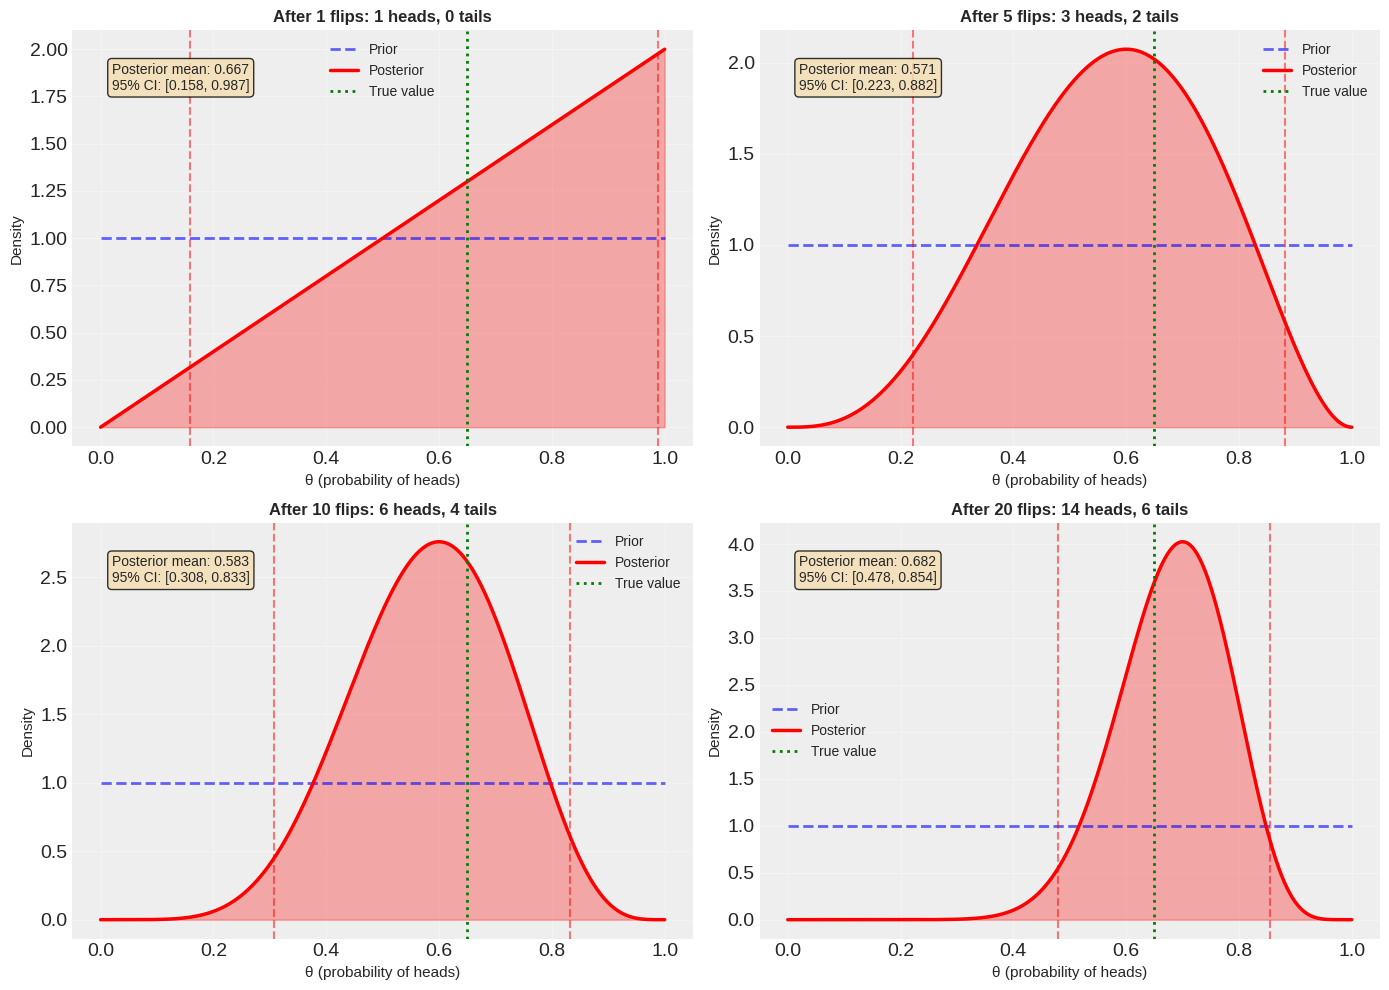

In [4]:
# Prior parameters (uniform prior: Beta(1,1))
alpha_prior = 1
beta_prior = 1

# We'll update after seeing 1, 5, 10, and 20 flips
update_points = [1, 5, 10, 20]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

theta_range = np.linspace(0, 1, 1000)

for idx, n in enumerate(update_points):
    # Get data up to this point
    data_so_far = coin_flips[:n]
    heads = data_so_far.sum()
    tails = n - heads

    # Prior
    prior_dist = stats.beta(alpha_prior, beta_prior)

    # Posterior (using conjugacy)
    alpha_post = alpha_prior + heads
    beta_post = beta_prior + tails
    posterior_dist = stats.beta(alpha_post, beta_post)

    # Plot
    axes[idx].plot(theta_range, prior_dist.pdf(theta_range),
                   'b--', label='Prior', linewidth=2, alpha=0.6)
    axes[idx].plot(theta_range, posterior_dist.pdf(theta_range),
                   'r-', label='Posterior', linewidth=2.5)
    axes[idx].axvline(true_p, color='green', linestyle=':',
                      linewidth=2, label='True value')
    axes[idx].fill_between(theta_range, posterior_dist.pdf(theta_range),
                           alpha=0.3, color='red')

    # Add credible interval
    ci_lower, ci_upper = posterior_dist.ppf([0.025, 0.975])
    axes[idx].axvline(ci_lower, color='red', linestyle='--', alpha=0.5)
    axes[idx].axvline(ci_upper, color='red', linestyle='--', alpha=0.5)

    axes[idx].set_title(f'After {n} flips: {heads} heads, {tails} tails',
                        fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('θ (probability of heads)', fontsize=11)
    axes[idx].set_ylabel('Density', fontsize=11)
    axes[idx].legend(fontsize=10)
    axes[idx].grid(True, alpha=0.3)

    # Add text with posterior mean and 95% CI
    post_mean = alpha_post / (alpha_post + beta_post)
    axes[idx].text(0.02, axes[idx].get_ylim()[1]*0.85,
                   f'Posterior mean: {post_mean:.3f}\n95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]',
                   fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

We notice that:
1. The posterior gets narrower (more certain) as we see more data
2. The posterior mean converges toward the true value
3. Early on, the prior has more influence; later, data dominates

## Python for Markov Chain Monte Carlo ([PyMC](https://www.pymc.io/))
PyMC is a probabilistic programming library for Python that allows users to build Bayesian models with a simple Python API and fit them using Markov chain Monte Carlo (MCMC) methods.

In principle, if we are familiar with the basics of Python, PyMC will be boiled down to learning a couple of new syntaxes. The analysis of the results is more depenedent of our understanding of the model than the PyMC itself.

### Example

Now let's do the same above mentioned analysis using PyMC framework. It will:
1. Use MCMC (Markov Chain Monte Carlo) to sample from the posterior
2. Give us the full posterior distribution
3. Handle much more complex models that don't have analytical solutions

In [5]:
# Our observed data
observed_flips = coin_flips
n_observations = len(observed_flips)
import pymc as pm

# Build the PyMC model
with pm.Model() as coin_model:
    # Prior: Beta(1, 1) which is uniform on [0, 1]
    theta = pm.Beta('theta', alpha=1, beta=1)

    # Likelihood: Binomial distribution
    y = pm.Binomial('y', n=1, p=theta, observed=observed_flips)

    # Sample from the posterior
    trace = pm.sample(2000, tune=1000, chains=3, random_seed=42, return_inferencedata=True)

print("\nSampling complete!")

Output()


Sampling complete!


#### PyMC Syntaxes

Let's break down what we just did:

1. **`with pm.Model() as coin_model:`** Creates a PyMC model context
2. **`theta = pm.Beta('theta', alpha=1, beta=1)`** Defines our prior belief about θ
3. **`y = pm.Binomial('y', n=1, p=theta, observed=observed_flips)`** Likelihood function with observed data
4. **`trace = pm.sample(...)`** Samples from the posterior using MCMC
   - `2000` samples from the posterior
   - `tune=1000` samples to calibrate the sampler (discarded)
   - `chain`
   - Returns an `InferenceData` object with our results

#### Visualizing the Posterior

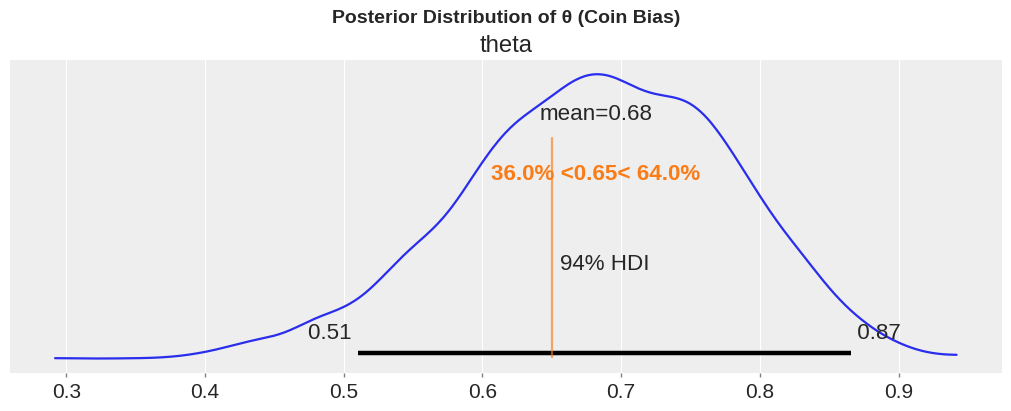


Posterior Summary:
        mean     sd  hdi_3%  hdi_97%
theta  0.682  0.096    0.51    0.866


In [ ]:
# Plot the posterior distribution
az.plot_posterior(trace, var_names=['theta'], ref_val=true_p, figsize=(10, 4))
plt.suptitle('Posterior Distribution of θ (Coin Bias)', fontsize=14, fontweight='bold')
plt.show()

# Print summary statistics
print("\nPosterior Summary:")
print(az.summary(trace, var_names=['theta'], kind='stats'))

#### Interpreting the Results

The posterior plot shows:
- **Mean**: Our best point estimate for θ
- **94% HDI** (Highest Density Interval): Range where we're 94% confident θ lies
- **Green line**: True value (which we normally wouldn't know!)

We can make probability statements like:
> "There is a 94% probability that the true probability of heads is between X and Y"

In [ ]:
# Let's answer specific questions using our posterior
theta_samples = trace.posterior['theta'].values.flatten()

# What's the probability that the coin is biased toward heads (θ > 0.5)?
prob_biased_heads = (theta_samples > 0.5).mean()
print(f"Probability that θ > 0.5: {prob_biased_heads:.2%}")

# What's the probability that the coin is heavily biased (θ > 0.7)?
prob_heavy_bias = (theta_samples > 0.7).mean()
print(f"Probability that θ > 0.7: {prob_heavy_bias:.2%}")

# What's the probability that the coin is approximately fair (0.45 < θ < 0.55)?
prob_fair = ((theta_samples > 0.45) & (theta_samples < 0.55)).mean()
print(f"Probability that coin is fair (0.45 < θ < 0.55): {prob_fair:.2%}")

Probability that θ > 0.5: 96.18%
Probability that θ > 0.7: 44.10%
Probability that coin is fair (0.45 < θ < 0.55): 8.18%


#### Posterior Predictive Distribution

One powerful aspect of Bayesian inference: we can simulate future data!

**Question**: If we flip this coin 100 more times, how many heads would we expect?

Output()

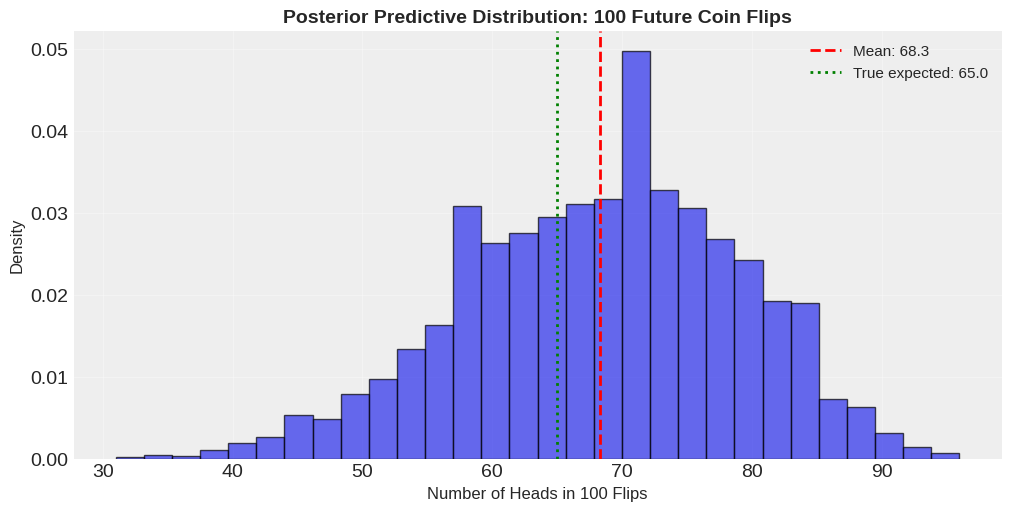


95% Credible Interval for heads in 100 flips: [46, 87]
Expected number of heads: 68.3


In [ ]:
# Generate posterior predictive samples
with coin_model:
    # Simulate 100 new coin flips using our posterior beliefs
    posterior_predictive = pm.sample_posterior_predictive(trace, random_seed=42)

# Then manually simulate 100 flips using the posterior theta samples
theta_samples = trace.posterior['theta'].values.flatten()
predicted_heads = np.random.binomial(n=100, p=theta_samples, size=len(theta_samples))

# Plot the distribution of predicted heads
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(predicted_heads, bins=30, edgecolor='black', alpha=0.7, density=True)
ax.axvline(predicted_heads.mean(), color='red', linestyle='--',
           linewidth=2, label=f'Mean: {predicted_heads.mean():.1f}')
ax.axvline(true_p * 100, color='green', linestyle=':',
           linewidth=2, label=f'True expected: {true_p * 100:.1f}')
ax.set_xlabel('Number of Heads in 100 Flips', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Posterior Predictive Distribution: 100 Future Coin Flips',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.show()

# Print credible interval for predictions
pred_ci = np.percentile(predicted_heads, [2.5, 97.5])
print(f"\n95% Credible Interval for heads in 100 flips: [{pred_ci[0]:.0f}, {pred_ci[1]:.0f}]")
print(f"Expected number of heads: {predicted_heads.mean():.1f}")

### Exercise 1
Modify the coin flip model to use a more informative prior: `Beta(10, 10)` (strong belief in fairness). How does this change your posterior?

In [ ]:
# Your code

### Exercise 2
Generate 200 coin flips instead of 20. How does this affect:
- The width of the posterior?
- The influence of the prior?

In [ ]:
# Your code